# Ekstraksi File MNIST-120k

File data MNIST-120k yang berasal dari dataset QMNIST tersebut tersimpan dalam format **Binary Pickle**. Karenanya kita akan menggunakan modul `pickle`, `numpy`, dan `matplotlib` untuk melakukan _load_ serta menampilkannya.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Load Mapping Label (ASCII)

Sebelum memuat gambar, kita muat terlebih dahulu relasi/hubungan antara label dataset EMNIST ByClass (bernilai `0-61`) dengan karakter aslinya (berdasarkan kode _ASCII_).


In [5]:
# Tentukan path dari file mapping
mapping_file_path = "archive/txt/emnist-byclass-mapping.txt"

# Load mapping file (mengandung referensi nilai label dengan kode ASCII sebenarnya)
df_mapping = pd.read_csv(mapping_file_path, sep=' ', header=None, names=['label', 'ascii_code'])
print("Susunan Mapping File (Head 5 pertama):")
display(df_mapping.head())

# Menyusun dictionary mapping dari label (angka 0-61) ke kode asli ASCII-nya
# Menggunakan `chr(ascii_code)` pada skrip nanti, kita bisa dapat huruf/angkanya langsung.
label_to_ascii = dict(zip(df_mapping['label'], df_mapping['ascii_code']))
# Test tampilkan
print(f"Contoh: Label 10 dikonversi menjadi huruf '{chr(label_to_ascii[10])}'")

Susunan Mapping File (Head 5 pertama):


,label,ascii_code
0,0,48
1,1,49
2,2,50
3,3,51
4,4,52


Contoh: Label 10 dikonversi menjadi huruf 'A'


## 2. Load & Preprocessing Data `Train`

Kita mulai terlebih dahulu dengan data _Training_. Sama seperti sebelumnya, kita sisipkan parameter tipe data memori menjadi 8-bit `np.uint8` untuk menghindari kemungkinan memori komputer (_RAM_) Crash (_OOM_) . Karena ini akan menyuplai ~697.000 file sekaligus.


In [6]:
train_file_path = "archive/csv/emnist-byclass-train.csv"

# Gunakan tipe data np.uint8 agar RAM tidak jebol! (RAM 100% dan OOM Killer aktif)
print(f"Loading data TRAIN from {train_file_path}...")
df_train = pd.read_csv(train_file_path, header=None, dtype=np.uint8)

# Pada file EMNIST / MNIST berbasis CSV standar:
# - Kolom pertama (index 0) adalah target label
# - Kolom sisanya (index 1 ke atas) merepresentasikan nilai piksel (784 pixel per gambar)

if df_train.shape[1] == 785:
    y_train = df_train.iloc[:, 0].values # Label Train
    X_train = df_train.iloc[:, 1:].values # Data Piksel Gambar Train
else:
    print("Peringatan: Jumlah kolom Train tidak sesuai.")

print(f"Shape of Data (X_train): {np.shape(X_train)}")
print(f"Shape of Labels (y_train): {np.shape(y_train)}")

# Hapus dataframe original dari memori RAM untuk membebaskan ruang memori
del df_train
print("Memory untuk df_train sudah dikosongkan.")

Loading data TRAIN from archive/csv/emnist-byclass-train.csv...
Shape of Data (X_train): (697932, 784)
Shape of Labels (y_train): (697932,)
Memory untuk df_train sudah dikosongkan.


## 3. Load & Preprocessing Data `Test`

Langkah yang sama persis namun kita jalankan pada data testing EMNIST ByClass (sekitar `~116.000` data gambar).


In [7]:
test_file_path = "archive/csv/emnist-byclass-test.csv"

# Gunakan tipe data np.uint8 kembali
print(f"Loading data TEST from {test_file_path}...")
df_test = pd.read_csv(test_file_path, header=None, dtype=np.uint8)

if df_test.shape[1] == 785:
    y_test = df_test.iloc[:, 0].values # Label Test
    X_test = df_test.iloc[:, 1:].values # Data Piksel Gambar Test
else:
    print("Peringatan: Jumlah kolom Test tidak sesuai.")

print(f"Shape of Data (X_test): {np.shape(X_test)}")
print(f"Shape of Labels (y_test): {np.shape(y_test)}")

del df_test
print("Memory untuk df_test sudah dikosongkan.")

Loading data TEST from archive/csv/emnist-byclass-test.csv...
Shape of Data (X_test): (116323, 784)
Shape of Labels (y_test): (116323,)
Memory untuk df_test sudah dikosongkan.


## 4. Visualisasi Dataset (Train Sample)

Contohkan _Sample_ _Reshape_ data dari dataset matriks Numpy **Training** ke plot. Matplotlib 28x28.


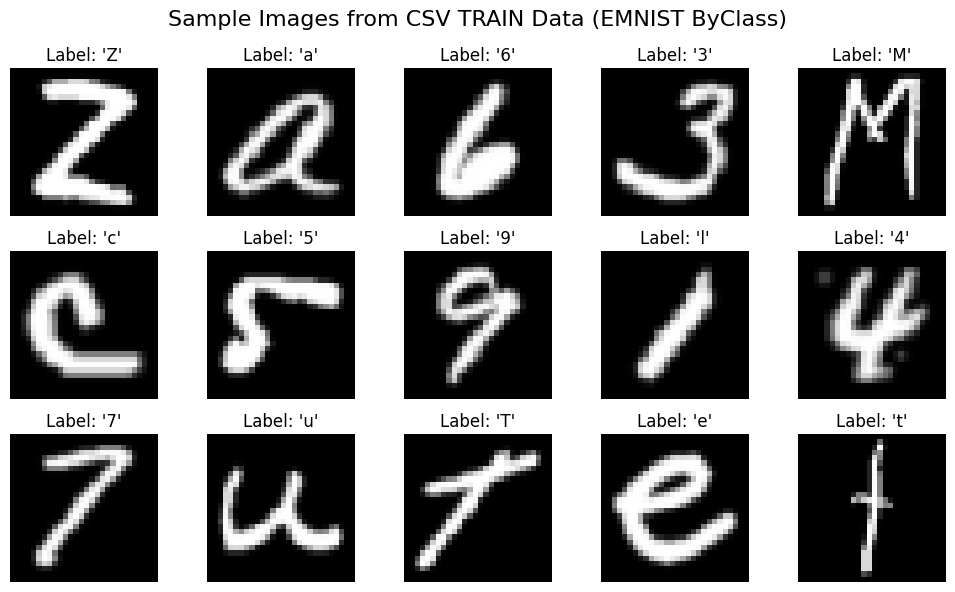

In [7]:
# Setting Figure untk plot
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
fig.suptitle('Sample Images from CSV TRAIN Data (EMNIST ByClass)', fontsize=16)

# Kita tampikan 15 gambar pertama
for i, ax in enumerate(axes.flatten()):
    if i < len(X_train):
        # Dalam dataset format CSV EMNIST seringkali gambar tersebut perlu melakukan transpose (.T)
        # karena format urutan pikselnya column-major saat diflatten, di rotasi 90 derajat.
        img = X_train[i].reshape(28, 28).T 
            
        ax.imshow(img, cmap='gray')
        
        # Mengekstrak label dari dictionary EMNIST ByClass (Mapping Label)
        # Kemudian diconvert dari kode asciinya menjadi karakter aslinya.
        label_id = int(y_train[i])
        ascii_code = label_to_ascii[label_id]
        character = chr(ascii_code)
        
        ax.set_title(f"Label: '{character}'")
    
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. (Opsional) Export ke format Numpy Arrays


In [ ]:
import os

# Menyimpan numpy array ke folder 'processed' (misal jika ingin dipakai ke file lain/notebook lain)
os.makedirs('processed/csv-dataset', exist_ok=True)

# Contoh jika ingin menghemat waktu komputasi read dataframe di proyek utama Anda
# np.save('processed/csv-dataset/X_train.npy', X_train)
# np.save('processed/csv-dataset/y_train.npy', y_train)
# np.save('processed/csv-dataset/X_test.npy', X_test)
# np.save('processed/csv-dataset/y_test.npy', y_test)

print("Status: Extraction array is ready to be saved if uncommented!")

Status: Extraction array is ready to be saved if uncommented!


## 6. Ekstrak Menjadi File Foto (.png) berdasarkan Folder (`Train` & `Test`)

Kita sekarang memisahkan blok kodingan ini menggunakan sebuah fungsi Python pembantu `extract_images(data_X, data_Y, dataset_type)`. Fungsi ini akan membantu kita mengeksekusinya untuk dataset _Train_ dan _Test_.

Nantinya seluruh direktori _output_ akan terkomposisi seperti `processed/emnist_byclass_images/train/large_a/...` dsb.


In [1]:
import os
import shutil

def migrate_extracted_images(dataset_type="train"):
    """
    Fungsi untuk mendeteksi folder hasil ekstraksi sebelumnya di 'processed/' 
    lalu memindahkan/meng-copy gambarnya ke folder 'Gambo/' dengan format nama yang baru.
    """
    gambo_split = dataset_type.capitalize() 
    source_base = f"processed/emnist_byclass_images/{dataset_type}"
    target_base = f"Gambo/{gambo_split}/Normal"
    
    if not os.path.exists(source_base):
        print(f"Melewati: Direktori {source_base} tidak ditemukan.")
        return

    os.makedirs(target_base, exist_ok=True)
    print(f"Sedang memigrasikan gambar dari {source_base} ke {target_base}...")

    # Membaca sub-folder yang sudah ada (misal: digit_0, lower_a, upper_A)
    for folder_name in os.listdir(source_base):
        source_dir = os.path.join(source_base, folder_name)
        if not os.path.isdir(source_dir):
            continue
            
        # Ambil karakter aslinya dari nama folder pengelompokannya
        if folder_name.startswith("digit_") or folder_name.startswith("lower_") or folder_name.startswith("upper_"):
            character = folder_name.split("_")[1]
        else:
            continue
            
        # Konversi ke format Hex ASCII (misalnya 'A' jadi '41')
        ascii_code = ord(character)
        hex_code = format(ascii_code, 'X')
        target_folder_name = f"{character}-{hex_code}"
        
        target_dir = os.path.join(target_base, target_folder_name)
        os.makedirs(target_dir, exist_ok=True)
        
        # Looping untuk meng-copy file gambar ke tempat tujuan
        for file_name in os.listdir(source_dir):
            source_file = os.path.join(source_dir, file_name)
            
            # Mendapatkan index file asli (dari format lama misal: img_train_59.png)
            # Menjadi: A-41_59.png
            idx = file_name.split('_')[-1].split('.')[0]
            new_file_name = f"{character}-{hex_code}_{idx}.png"
            target_file = os.path.join(target_dir, new_file_name)
            
            # Jika opsi user: "coba untuk hapus file yang sudah ada" agar menimpa dari awal.
            if os.path.exists(target_file):
                os.remove(target_file)
                
            shutil.copy(source_file, target_file)

    print(f"-> Selesai! Klasifikasi {gambo_split} berhasil digabungkan ke: {target_base}")

# --- MIGRASI & PENGGABUNGAN DATA (TANPA EKSTRAK ULANG) ---

print("--- Memulai Penggabungan Dataset ke struktur file Gambo ---")
migrate_extracted_images(dataset_type="train")
migrate_extracted_images(dataset_type="test")

--- Memulai Penggabungan Dataset ke struktur file Gambo ---
Sedang memigrasikan gambar dari processed/emnist_byclass_images/train ke Gambo/Train/Normal...
-> Selesai! Klasifikasi Train berhasil digabungkan ke: Gambo/Train/Normal
Sedang memigrasikan gambar dari processed/emnist_byclass_images/test ke Gambo/Test/Normal...
-> Selesai! Klasifikasi Test berhasil digabungkan ke: Gambo/Test/Normal
